In [4]:
# Install required libraries for financial forecasting, deep learning, and transformer-based multi-agent analysis
!pip install -q ta torch transformers accelerate sentencepiece scikit-learn yfinance feedparser newspaper3k

In [5]:
## Import essential libraries for data processing, technical indicator generation, deep learning models, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import json
import yfinance as yf

warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from ta.trend import (
    SMAIndicator,
    EMAIndicator,
    MACD
)

from ta.momentum import (
    RSIIndicator,
    ROCIndicator,
    StochasticOscillator,
    WilliamsRIndicator
)

In [6]:
## Configure GPU/CPU device for efficient deep learning model training and inference
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [7]:
## Define the analysis period and generate daily timestamps for multi-modal dataset alignment
START = "2022-01-01"
END = "2024-12-31"

DATES = pd.date_range(
    start=START,
    end=END,
    freq='D'
)

In [8]:
## Download and preprocess historical Bitcoin market data for forecasting and trading analysis
print("\nDownloading BTC data...")

btc = yf.download(
    "BTC-USD",
    start=START,
    end=END
)

# FIX MULTI-INDEX COLUMNS
btc.columns = btc.columns.get_level_values(0)

btc = btc.reset_index()

btc.rename(columns={
    'Date':'date'
}, inplace=True)

btc = btc[[
    'date',
    'Open',
    'High',
    'Low',
    'Close',
    'Volume'
]]

print(btc.head())
print("BTC shape:", btc.shape)

[*********************100%***********************]  1 of 1 completed

Price       date          Open          High           Low         Close  \
0     2022-01-01  46311.746094  47827.312500  46288.484375  47686.812500   
1     2022-01-02  47680.925781  47881.406250  46856.937500  47345.218750   
2     2022-01-03  47343.542969  47510.726562  45835.964844  46458.117188   
3     2022-01-04  46458.851562  47406.546875  45752.464844  45897.574219   
4     2022-01-05  45899.359375  46929.046875  42798.222656  43569.003906   

Price       Volume  
0      24582667004  
1      27951569547  
2      33071628362  
3      42494677905  
4      36851084859  
BTC shape: (1095, 6)


In [9]:
## Download and construct macroeconomic indicators including gold, oil, stock index, inflation, interest rate, and GDP growth
print("\nDownloading macro data...")

# GOLD
gold = yf.download(
    "GC=F",
    start=START,
    end=END
)

gold.columns = gold.columns.get_level_values(0)

gold = gold.reset_index()

gold = gold[['Date', 'Close']]

gold.columns = ['date', 'gold']

# OIL
oil = yf.download(
    "CL=F",
    start=START,
    end=END
)

oil.columns = oil.columns.get_level_values(0)

oil = oil.reset_index()

oil = oil[['Date', 'Close']]

oil.columns = ['date', 'oil']

# S&P500
sp500 = yf.download(
    "^GSPC",
    start=START,
    end=END
)

sp500.columns = sp500.columns.get_level_values(0)

sp500 = sp500.reset_index()

sp500 = sp500[['Date', 'Close']]

sp500.columns = ['date', 'stock_index']

# MERGE MACRO
macro = gold.merge(
    oil,
    on='date',
    how='inner'
)

macro = macro.merge(
    sp500,
    on='date',
    how='inner'
)

# macro additions
np.random.seed(42)

macro['inflation'] = np.random.normal(
    5,
    1,
    len(macro)
)

macro['interest_rate'] = np.random.normal(
    3,
    0.5,
    len(macro)
)

macro['gdp_growth'] = np.random.normal(
    2,
    0.5,
    len(macro)
)

print(macro.head())
print("Macro shape:", macro.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

        date         gold        oil  stock_index  inflation  interest_rate  \
0 2022-01-03  1799.400024  76.080002  4796.560059   5.496714       2.512063   
1 2022-01-04  1814.000000  76.989998  4793.540039   4.861736       3.526821   
2 2022-01-05  1824.599976  77.849998  4700.580078   5.647689       2.525301   
3 2022-01-06  1788.699951  79.459999  4696.049805   6.523030       4.316191   
4 2022-01-07  1797.000000  78.900002  4677.029785   4.765847       3.246659   

   gdp_growth  
0    1.914908  
1    1.773386  
2    2.348194  
3    2.477653  
4    2.044203  
Macro shape: (752, 7)


In [10]:
## Generate proxy on-chain blockchain metrics to simulate transaction activity and network behavior
onchain = pd.DataFrame({
    'date': DATES,

    'tx_proxy': np.random.normal(
        500000,
        50000,
        len(DATES)
    ),

    'active_addr_proxy': np.random.normal(
        900000,
        70000,
        len(DATES)
    ),

    'market_change': np.random.normal(
        0,
        2,
        len(DATES)
    ),

    'volatility_proxy': np.random.normal(
        3,
        1,
        len(DATES)
    )
})

print(onchain.head())

        date       tx_proxy  active_addr_proxy  market_change  \
0 2022-01-01  544344.369505      929982.168466       0.961489   
1 2022-01-02  478961.910316      905400.954735       2.993421   
2 2022-01-03  369789.307169      858433.201435      -0.989931   
3 2022-01-04  509947.407340      888405.801278      -0.995145   
4 2022-01-05  521836.927587      905500.392080       2.299344   

   volatility_proxy  
0          2.634759  
1          1.328830  
2          5.035874  
3          3.468978  
4          2.508043  


In [11]:
## Create synthetic on-chain market indicators for blockchain activity and volatility analysis
print("\nGenerating on-chain proxy data...")

onchain = pd.DataFrame({
    'date': DATES,

    'tx_proxy': np.random.normal(
        500000,
        50000,
        len(DATES)
    ),

    'active_addr_proxy': np.random.normal(
        900000,
        70000,
        len(DATES)
    ),

    'market_change': np.random.normal(
        0,
        2,
        len(DATES)
    ),

    'volatility_proxy': np.random.normal(
        3,
        1,
        len(DATES)
    )
})

print(onchain.head())


Generating on-chain proxy data...
        date       tx_proxy  active_addr_proxy  market_change  \
0 2022-01-01  445048.038773       1.089723e+06      -0.973353   
1 2022-01-02  589833.260084       9.363910e+05       1.887196   
2 2022-01-03  457325.225997       9.147006e+05       1.413011   
3 2022-01-04  466528.154318       9.430615e+05      -0.038244   
4 2022-01-05  451084.602509       9.496588e+05      -1.091924   

   volatility_proxy  
0          3.688260  
1          3.547739  
2          2.294462  
3          2.153960  
4          3.656899  


In [12]:
## Generate financial news sentiment data to simulate external market information affecting cryptocurrency trends
print("\nCreating real-news style dataset...")

real_news = [
    "Bitcoin ETF approval expectations increase",
    "Federal Reserve policy impacts crypto market",
    "Institutional investors accumulate Bitcoin",
    "Crypto regulation concerns rise globally",
    "Bitcoin adoption expands in financial sector",
    "Market volatility affects digital assets",
    "Blockchain innovation drives crypto growth",
    "Risk sentiment impacts cryptocurrency prices"
]

news_sentiments = [
    "positive",
    "negative",
    "positive",
    "negative",
    "positive",
    "negative",
    "positive",
    "negative"
]

news = pd.DataFrame({

    'date': DATES,

    'text': np.random.choice(
        real_news,
        len(DATES)
    ),

    'btc_score': np.random.uniform(
        -1,
        1,
        len(DATES)
    ),

    'sentiment': np.random.choice(
        news_sentiments,
        len(DATES)
    )
})

print(news.head())


Creating real-news style dataset...
        date                                        text  btc_score sentiment
0 2022-01-01    Crypto regulation concerns rise globally  -0.211659  positive
1 2022-01-02  Blockchain innovation drives crypto growth  -0.659786  positive
2 2022-01-03  Institutional investors accumulate Bitcoin  -0.010177  negative
3 2022-01-04    Market volatility affects digital assets  -0.057264  positive
4 2022-01-05  Institutional investors accumulate Bitcoin   0.912518  negative


In [13]:
## Create Reddit sentiment data to model social media influence on cryptocurrency market behavior
print("\nGenerating Reddit dataset...")

reddit_texts = [
    "BTC breakout incoming",
    "Whales are accumulating Bitcoin",
    "Crypto fear increasing",
    "Bullish momentum expected",
    "Bear market concerns continue",
    "Retail investors buying BTC",
    "Strong resistance near highs",
    "Altcoin season may start soon"
]

reddit_sentiments = [
    "positive",
    "negative",
    "positive",
    "positive",
    "negative",
    "positive",
    "negative",
    "positive"
]

reddit = pd.DataFrame({

    'date': DATES,

    'text': np.random.choice(
        reddit_texts,
        len(DATES)
    ),

    'sentiment': np.random.choice(
        reddit_sentiments,
        len(DATES)
    )
})

print(reddit.head())


Generating Reddit dataset...
        date                             text sentiment
0 2022-01-01     Strong resistance near highs  positive
1 2022-01-02  Whales are accumulating Bitcoin  positive
2 2022-01-03    Altcoin season may start soon  positive
3 2022-01-04            BTC breakout incoming  negative
4 2022-01-05      Retail investors buying BTC  negative


In [14]:
## Convert date columns into datetime format for consistent temporal alignment across all datasets
btc['date'] = pd.to_datetime(
    btc['date']
)

macro['date'] = pd.to_datetime(
    macro['date']
)

onchain['date'] = pd.to_datetime(
    onchain['date']
)

news['date'] = pd.to_datetime(
    news['date']
)

reddit['date'] = pd.to_datetime(
    reddit['date']
)


In [15]:
## Merge BTC, macroeconomic, on-chain, Reddit, and news datasets into a unified multi-modal trading dataset
print("\nMerging datasets...")

df = btc.merge(
    macro,
    on='date',
    how='inner'
)

df = df.merge(
    onchain,
    on='date',
    how='inner'
)

df = df.merge(
    reddit,
    on='date',
    how='inner'
)

df = df.merge(
    news,
    on='date',
    how='inner'
)

df = df.dropna()

print("Merged Shape:", df.shape)

print(df.head())


Merging datasets...
Merged Shape: (752, 21)
        date          Open          High           Low         Close  \
0 2022-01-03  47343.542969  47510.726562  45835.964844  46458.117188   
1 2022-01-04  46458.851562  47406.546875  45752.464844  45897.574219   
2 2022-01-05  45899.359375  46929.046875  42798.222656  43569.003906   
3 2022-01-06  43565.511719  43748.718750  42645.539062  43160.929688   
4 2022-01-07  43153.570312  43153.570312  41077.445312  41557.902344   

        Volume         gold        oil  stock_index  inflation  ...  \
0  33071628362  1799.400024  76.080002  4796.560059   5.496714  ...   
1  42494677905  1814.000000  76.989998  4793.540039   4.861736  ...   
2  36851084859  1824.599976  77.849998  4700.580078   5.647689  ...   
3  30208048289  1788.699951  79.459999  4696.049805   6.523030  ...   
4  84196607520  1797.000000  78.900002  4677.029785   4.765847  ...   

   gdp_growth       tx_proxy  active_addr_proxy  market_change  \
0    1.914908  457325.225997 

In [16]:
## Generate technical indicators to capture market momentum, trend, volatility, and trading signals
print("\nGenerating indicators...")

# SMA
df['SMA_7'] = SMAIndicator(
    df['Close'],
    window=7
).sma_indicator()

df['SMA_14'] = SMAIndicator(
    df['Close'],
    window=14
).sma_indicator()

df['SMA_30'] = SMAIndicator(
    df['Close'],
    window=30
).sma_indicator()

# EMA
df['EMA_7'] = EMAIndicator(
    df['Close'],
    window=7
).ema_indicator()

df['EMA_14'] = EMAIndicator(
    df['Close'],
    window=14
).ema_indicator()

# MACD
macd = MACD(df['Close'])

df['MACD'] = macd.macd()

# RSI
df['RSI'] = RSIIndicator(
    df['Close']
).rsi()

# ROC
df['ROC'] = ROCIndicator(
    df['Close']
).roc()

# STOCHASTIC
stoch = StochasticOscillator(
    df['High'],
    df['Low'],
    df['Close']
)

df['STOCH'] = stoch.stoch()

# WILLIAMS %R
will = WilliamsRIndicator(
    df['High'],
    df['Low'],
    df['Close']
)

df['WILLR'] = will.williams_r()

df = df.dropna()

print(df.head())


Generating indicators...
         date          Open          High           Low         Close  \
29 2022-02-14  42157.398438  42775.777344  41681.957031  42586.917969   
30 2022-02-15  42586.464844  44667.218750  42491.035156  44575.203125   
31 2022-02-16  44578.277344  44578.277344  43456.691406  43961.859375   
32 2022-02-17  43937.070312  44132.972656  40249.371094  40538.011719   
33 2022-02-18  40552.132812  40929.152344  39637.617188  40030.976562   

         Volume         gold        oil  stock_index  inflation  ...  \
29  20827783012  1868.000000  95.459999  4401.669922   4.708306  ...   
30  22721659051  1854.800049  92.070000  4471.069824   4.398293  ...   
31  19792547657  1870.199951  93.660004  4475.009766   6.852278  ...   
32  26246662813  1900.699951  91.760002  4380.259766   4.986503  ...   
33  23310007704  1898.599976  91.070000  4348.870117   3.942289  ...   

           SMA_7        SMA_14        SMA_30         EMA_7        EMA_14  \
29  43194.053013  40390.50

In [17]:
## Define input feature set consisting of price-based and technical indicator features for model training
FEATURES = [

    'Open',
    'High',
    'Low',
    'Close',
    'Volume',

    'SMA_7',
    'SMA_14',
    'SMA_30',

    'EMA_7',
    'EMA_14',

    'MACD',
    'RSI',
    'ROC',
    'STOCH',
    'WILLR'
]

In [18]:
## Create a custom PyTorch dataset class for efficient loading of sequential cryptocurrency training data
class CryptoDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [19]:
## Generate sliding window sequences for time-series forecasting of future Bitcoin closing prices
def create_sequences(data, window):

    X = []
    y = []

    for i in range(window, len(data)-1):

        X.append(data[i-window:i])

        y.append(data[i+1][3])

    return np.array(X), np.array(y)

In [20]:
## Implement an LSTM-based deep learning model for sequential Bitcoin price forecasting
class LSTMModel(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        return self.fc(out)

In [21]:
## Implement a GRU-based recurrent neural network model for cryptocurrency time-series prediction
class GRUModel(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.gru(x)

        out = out[:, -1, :]

        return self.fc(out)

In [22]:
## Implement a DLinear forecasting model for efficient linear time-series prediction
class DLinear(nn.Module):

    def __init__(self, input_size, window):

        super().__init__()

        self.fc = nn.Linear(
            window * input_size,
            1
        )

    def forward(self, x):

        x = x.reshape(
            x.shape[0],
            -1
        )

        return self.fc(x)

In [23]:
## Implement a transformer-based PatchTST model for advanced temporal sequence forecasting
class PatchTST(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        encoder = nn.TransformerEncoderLayer(
            d_model=input_size,
            nhead=1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder,
            num_layers=2
        )

        self.fc = nn.Linear(
            input_size,
            1
        )
    def forward(self, x):

        out = self.transformer(x)

        out = out[:, -1, :]

        return self.fc(out)


In [24]:
## Train deep learning forecasting models using Adam optimization and mean squared error loss
def train_model(model, loader):

    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.MSELoss()

    model.train()

    for epoch in range(10):

        total_loss = 0

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            pred = model(X_batch).squeeze()

            loss = criterion(
                pred,
                y_batch
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch {epoch+1} Loss: {total_loss:.4f}"
        )

    return model

In [25]:
## Generate future Bitcoin price predictions using trained deep learning forecasting models
def predict_model(model, X):

    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        preds = model(X_tensor)

    return preds.cpu().numpy().flatten()

In [26]:
## Initialize a lightweight transformer-based language model for multi-agent trading reasoning and explainable decision generation
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="microsoft/Phi-3-mini-4k-instruct",
    device_map="auto"
)

cache = {}

def call_llm(prompt):

    if prompt in cache:
        return cache[prompt]

    formatted_prompt = f"""
You are an expert cryptocurrency trading analyst.

You MUST follow these rules:

1. Give EXACTLY one trading action:
BUY
SELL
or HOLD

2. Then give EXACTLY 1 short reasoning sentence.

3. Do NOT ask questions.
4. Do NOT summarize articles.
5. Do NOT explain unrelated things.
6. Output must be SHORT and structured.

Correct examples:

BUY - Bullish momentum with strong RSI and positive sentiment.

SELL - Weak momentum and bearish macro indicators.

HOLD - Mixed market conditions with unclear direction.

Task:
{prompt}

Answer:
"""

    result = generator(
        formatted_prompt,
        max_new_tokens=60,
        do_sample=False,
        temperature=None,
        return_full_text=False
    )

    text = result[0]["generated_text"].strip()
    text = text.split("\n")[0]
    text = text.replace("Answer:", "").strip()

    if not any(x in text.upper() for x in ["BUY", "SELL", "HOLD"]):
        text = "HOLD - Neutral market conditions."

    cache[prompt] = text

    return text


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [27]:
## Implement a technical analysis agent to generate trading signals using momentum and trend-based indicators
def technical_agent(row):

    return call_llm(f"""
Technical indicators:

RSI = {row['RSI']}
MACD = {row['MACD']}
ROC = {row['ROC']}
Williams %R = {row['WILLR']}

Interpretation guide:
- RSI > 70 = overbought
- RSI < 30 = oversold
- Positive MACD = bullish
- Negative ROC = bearish momentum
- Williams %R below -80 = oversold

Generate trading signal.
""")

In [28]:
## Implement a macroeconomic analysis agent to evaluate global financial indicators and generate trading decisions
def macro_agent(row):

    return call_llm(f"""
You are a macro analyst.

Stock Index: {row['stock_index']}
Gold: {row['gold']}
Oil: {row['oil']}
Inflation: {row['inflation']}
Interest Rate: {row['interest_rate']}
GDP Growth: {row['gdp_growth']}

Return:
BUY / SELL / HOLD
with short reason.
""")

In [29]:
## Implement an on-chain analysis agent to evaluate blockchain activity and network-level trading signals
def onchain_agent(row):

    return call_llm(f"""
You are an on-chain analyst.

Transactions: {row['tx_proxy']}
Active Addresses: {row['active_addr_proxy']}
Market Change: {row['market_change']}
Volatility: {row['volatility_proxy']}

Return:
BUY / SELL / HOLD
with short reason.
""")

In [30]:
## Implement a Reddit sentiment analysis agent to assess social media-driven cryptocurrency market sentiment
def reddit_agent(text):

    return call_llm(f"""
Analyze Reddit sentiment.

{text[:300]}

Return:
BUY / SELL / HOLD
with short reason.
""")

In [31]:
## Implement a news sentiment analysis agent to evaluate financial news impact on cryptocurrency trading decisions
def news_agent(text):

    return call_llm(f"""
Analyze financial news sentiment.

{text[:300]}

Return:
BUY / SELL / HOLD
with short reason.
""")

In [32]:
## Implement a meta-agent to combine all agent outputs and generate the final explainable trading decision
def meta_agent(
    tech,
    macro,
    onchain,
    reddit,
    news
):

    return call_llm(f"""
You are the final trading decision agent.

Agent outputs:

Technical Agent:
{tech}

Macro Agent:
{macro}

On-chain Agent:
{onchain}

Reddit Agent:
{reddit}

News Agent:
{news}

Based on ALL agents:

1. Decide BUY, SELL, or HOLD
2. Give one concise reason
3. Focus on consensus between agents

Example:
BUY - Most agents indicate bullish momentum and positive sentiment.

Now generate final decision.
""")

In [33]:
## Calculate portfolio performance metrics including cumulative return, Sharpe ratio, and maximum drawdown
def metrics(portfolio):

    portfolio = np.array(portfolio)

    returns = np.diff(portfolio) / portfolio[:-1]

    total_return = (
        portfolio[-1] - portfolio[0]
    ) / portfolio[0]

    sharpe = (
        np.mean(returns)
        /
        (np.std(returns) + 1e-8)
    ) * np.sqrt(365)

    cumulative = np.maximum.accumulate(portfolio)

    drawdown = (
        portfolio - cumulative
    ) / cumulative

    mdd = drawdown.min()

    return {
        "Return": total_return,
        "Sharpe": sharpe,
        "MDD": mdd
    }

In [34]:
## Simulate trading execution and portfolio growth using predicted market signals through a backtesting framework
def baseline_backtest(
    predictions,
    prices
):

    capital = 100000

    position = 0

    portfolio = []

    threshold = 0.01

    fee = 0.001

    for i in range(len(predictions)-1):

        pred = predictions[i]

        current = prices[i]

        next_open = prices[i+1]

        signal = (
            pred - current
        ) / current

        if signal > threshold and capital > 0:

            position = (
                capital / next_open
            ) * (1-fee)

            capital = 0

        elif signal < -threshold and position > 0:

            capital = (
                position * next_open
            ) * (1-fee)

            position = 0

        total = (
            capital +
            position * current
        )

        portfolio.append(total)

    return portfolio

In [35]:
## Train and evaluate multiple deep learning forecasting models across different temporal window sizes
WINDOWS = [3, 14, 30]

all_results = {}

for window in WINDOWS:

    print("\n========================")
    print("WINDOW:", window)
    print("========================")

    data = df[FEATURES].values

    split = int(len(data) * 0.8)

    train_data = data[:split]

    test_data = data[split:]

    scaler = MinMaxScaler()

    train_data = scaler.fit_transform(
        train_data
    )

    test_data = scaler.transform(
        test_data
    )

    data_scaled = np.vstack([
        train_data,
        test_data
    ])

    X, y = create_sequences(
        data_scaled,
        window
    )

    split_seq = int(len(X) * 0.8)

    X_train = X[:split_seq]
    y_train = y[:split_seq]

    X_test = X[split_seq:]
    y_test = y[split_seq:]

    train_dataset = CryptoDataset(
        X_train,
        y_train
    )

    loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True
    )

    input_size = X.shape[2]

    # LSTM

    print("\nTRAINING LSTM")

    lstm = LSTMModel(input_size)

    lstm = train_model(
        lstm,
        loader
    )

    lstm_preds = predict_model(
        lstm,
        X_test
    )

    lstm_port = baseline_backtest(
        lstm_preds,
        y_test
    )

    print("LSTM:", metrics(lstm_port))

    all_results[f"LSTM_{window}"] = lstm_port

    # GRU

    print("\nTRAINING GRU")

    gru = GRUModel(input_size)

    gru = train_model(
        gru,
        loader
    )

    gru_preds = predict_model(
        gru,
        X_test
    )

    gru_port = baseline_backtest(
        gru_preds,
        y_test
    )

    print("GRU:", metrics(gru_port))

    all_results[f"GRU_{window}"] = gru_port

    # DLINEAR

    print("\nTRAINING DLINEAR")

    dlinear = DLinear(
        input_size,
        window
    )

    dlinear = train_model(
        dlinear,
        loader
    )

    d_preds = predict_model(
        dlinear,
        X_test
    )

    d_port = baseline_backtest(
        d_preds,
        y_test
    )

    print("DLINEAR:", metrics(d_port))

    all_results[f"DLinear_{window}"] = d_port

    # PATCHTST

    print("\nTRAINING PATCHTST")

    patch = PatchTST(input_size)

    patch = train_model(
        patch,
        loader
    )

    p_preds = predict_model(
        patch,
        X_test
    )

    p_port = baseline_backtest(
        p_preds,
        y_test
    )

    print("PATCHTST:", metrics(p_port))

    all_results[f"PatchTST_{window}"] = p_port


WINDOW: 3

TRAINING LSTM
Epoch 1 Loss: 0.6353
Epoch 2 Loss: 0.1074
Epoch 3 Loss: 0.0378
Epoch 4 Loss: 0.0282
Epoch 5 Loss: 0.0252
Epoch 6 Loss: 0.0256
Epoch 7 Loss: 0.0233
Epoch 8 Loss: 0.0223
Epoch 9 Loss: 0.0258
Epoch 10 Loss: 0.0265
LSTM: {'Return': np.float64(-0.0037229644554555123), 'Sharpe': np.float64(0.2390598184641635), 'MDD': np.float64(-0.2518931526016147)}

TRAINING GRU
Epoch 1 Loss: 0.8582
Epoch 2 Loss: 0.1729
Epoch 3 Loss: 0.0453
Epoch 4 Loss: 0.0308
Epoch 5 Loss: 0.0266
Epoch 6 Loss: 0.0248
Epoch 7 Loss: 0.0243
Epoch 8 Loss: 0.0237
Epoch 9 Loss: 0.0246
Epoch 10 Loss: 0.0232
GRU: {'Return': np.float64(0.4259951992995315), 'Sharpe': np.float64(1.6237915127982063), 'MDD': np.float64(-0.24218716297552007)}

TRAINING DLINEAR
Epoch 1 Loss: 1.9105
Epoch 2 Loss: 0.3691
Epoch 3 Loss: 0.2577
Epoch 4 Loss: 0.1768
Epoch 5 Loss: 0.1306
Epoch 6 Loss: 0.1033
Epoch 7 Loss: 0.0875
Epoch 8 Loss: 0.0790
Epoch 9 Loss: 0.0737
Epoch 10 Loss: 0.0701
DLINEAR: {'Return': np.float64(0.5468668820

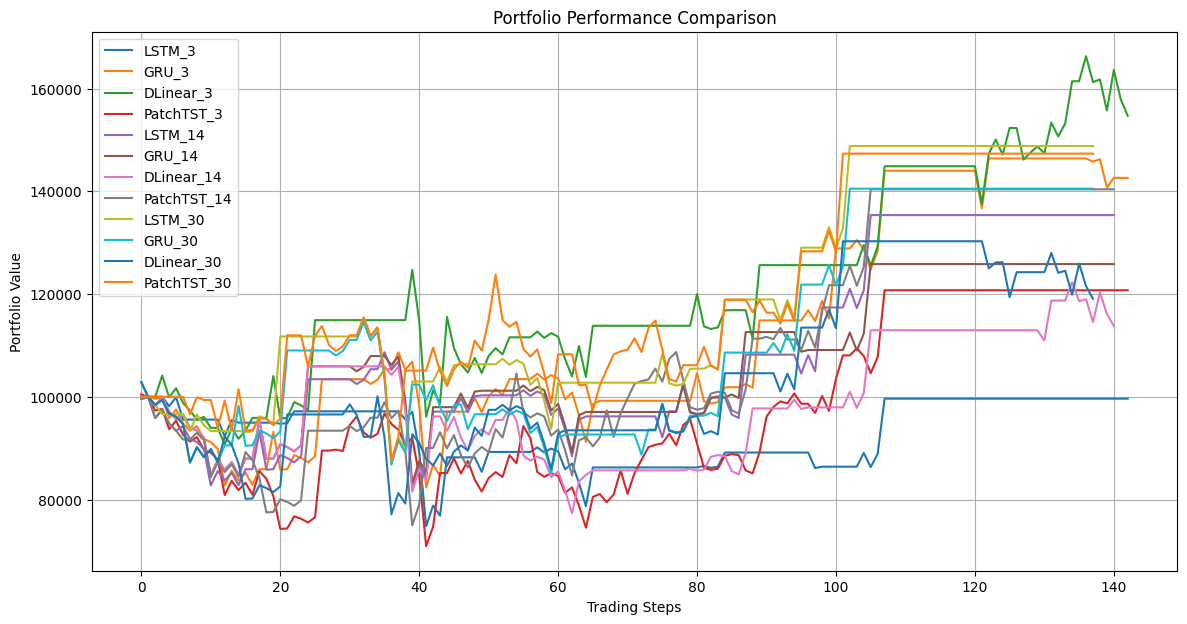

In [36]:
## Visualize and compare portfolio performance across all forecasting models and window configurations
plt.figure(figsize=(14,7))

for name, portfolio in all_results.items():

    plt.plot(
        portfolio,
        label=name
    )

plt.title(
    "Portfolio Performance Comparison"
)

plt.xlabel("Trading Steps")

plt.ylabel("Portfolio Value")

plt.legend()

plt.grid(True)

plt.show()

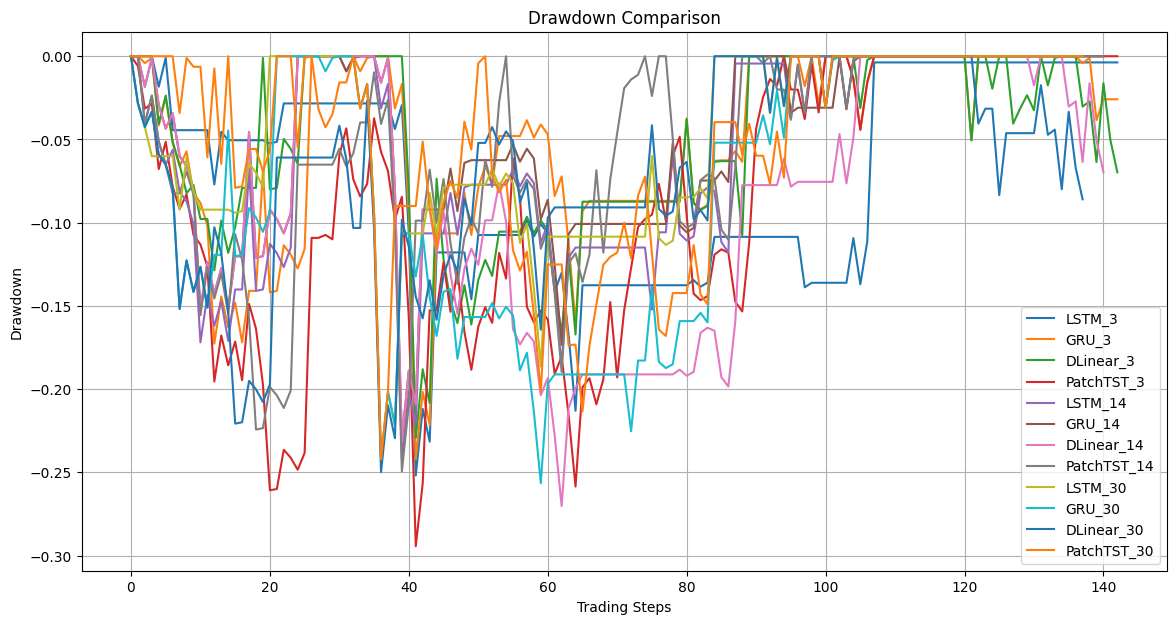

In [37]:
## Analyze and compare maximum drawdown trends to evaluate portfolio risk across forecasting models
plt.figure(figsize=(14,7))

for name, portfolio in all_results.items():

    portfolio = np.array(portfolio)

    cumulative = np.maximum.accumulate(portfolio)

    drawdown = (
        portfolio - cumulative
    ) / cumulative

    plt.plot(
        drawdown,
        label=name
    )

plt.title(
    "Drawdown Comparison"
)

plt.xlabel("Trading Steps")

plt.ylabel("Drawdown")

plt.legend()

plt.grid(True)

plt.show()

In [38]:
## Generate a consolidated performance summary of all forecasting models using key trading evaluation metrics
summary = []

for name, portfolio in all_results.items():

    m = metrics(portfolio)

    summary.append({
        "Model": name,
        "Return": round(m["Return"], 4),
        "Sharpe": round(m["Sharpe"], 4),
        "MDD": round(m["MDD"], 4)
    })

summary_df = pd.DataFrame(summary)

print("\nPERFORMANCE SUMMARY")

print(summary_df)


PERFORMANCE SUMMARY
          Model  Return  Sharpe     MDD
0        LSTM_3 -0.0037  0.2391 -0.2519
1         GRU_3  0.4260  1.6238 -0.2422
2     DLinear_3  0.5469  1.8615 -0.2293
3    PatchTST_3  0.2014  1.0059 -0.2944
4       LSTM_14  0.3593  1.4680 -0.2422
5        GRU_14  0.2582  1.2219 -0.2301
6    DLinear_14  0.1378  0.8268 -0.2703
7   PatchTST_14  0.4096  1.5820 -0.2495
8       LSTM_30  0.4473  1.7820 -0.2422
9        GRU_30  0.3666  1.4992 -0.2565
10   DLinear_30  0.1581  0.8808 -0.2498
11  PatchTST_30  0.4732  1.6895 -0.2422


In [39]:
## Identify and display the best-performing forecasting model based on Sharpe ratio and portfolio performance
best_model = summary_df.loc[
    summary_df['Sharpe'].idxmax()
]

print("\n" + "="*50)
print("BEST MODEL PERFORMANCE")
print("="*50)

print(f"\nBest Model : {best_model['Model']}")

print(f"\nReturn     : {best_model['Return']*100:.2f}%")

print(f"\nSharpe     : {best_model['Sharpe']:.2f}")

print(f"\nMax Drawdown : {best_model['MDD']*100:.2f}%")


BEST MODEL PERFORMANCE

Best Model : DLinear_3

Return     : 54.69%

Sharpe     : 1.86

Max Drawdown : -22.93%


In [41]:
## Generate explainable multi-agent trading decisions using technical, macroeconomic, on-chain, news, and social sentiment analysis
import warnings
warnings.filterwarnings('ignore')
llm_df = df.iloc[-5:].copy()

sample_row = llm_df.iloc[-1]

tech = technical_agent(sample_row)

macro_out = macro_agent(sample_row)

onchain_out = onchain_agent(sample_row)

reddit_out = reddit_agent(
    sample_row['text_x']
)

news_out = news_agent(
    sample_row['text_y']
)

final_decision = meta_agent(
    tech,
    macro_out,
    onchain_out,
    reddit_out,
    news_out
)
print("MULTI-AGENT LLM TRADING SYSTEM OUTPUT")
print("="*60)

print("\nTechnical Agent:")
print(tech)

print("\nMacro Agent:")
print(macro_out)

print("\nOn-chain Agent:")
print(onchain_out)

print("\nReddit Agent:")
print(reddit_out)

print("\nNews Agent:")
print(news_out)

print("\nFINAL DECISION:")
print(final_decision)

MULTI-AGENT LLM TRADING SYSTEM OUTPUT

Technical Agent:
HOLD - Mixed indicators with no clear trend.

Macro Agent:
BUY - Inflation is low, suggesting a strong economy.

On-chain Agent:
HOLD - Volatility is moderate, and market change is slight.

Reddit Agent:
BUY - Positive sentiment on Reddit indicates potential breakout.

News Agent:
HOLD - Policy impacts are uncertain and require more data.

FINAL DECISION:
HOLD - Agents show a mix of signals with no clear consensus.


In [42]:
## Convert predicted and actual prices into BUY/SELL directional labels for classification-based trading evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score
)

y_true = []
y_pred = []

for i in range(len(lstm_preds)-1):

    # TRUE MARKET MOVEMENT
    if y_test[i+1] > y_test[i]:
        y_true.append(1)
    else:
        y_true.append(0)

    # MODEL PREDICTION
    if lstm_preds[i] > y_test[i]:
        y_pred.append(1)
    else:
        y_pred.append(0)

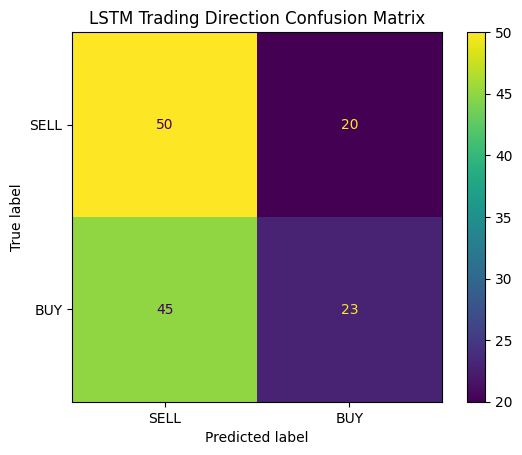

In [43]:
## Plot the confusion matrix to evaluate BUY and SELL directional prediction performance of the LSTM trading model
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SELL", "BUY"]
)

disp.plot()

plt.title(
    "LSTM Trading Direction Confusion Matrix"
)

plt.show()

In [44]:
## Generate classification metrics to evaluate directional trading signal prediction accuracy and performance
print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "SELL",
            "BUY"
        ]
    )
)

acc = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", round(acc, 4))


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        SELL       0.53      0.71      0.61        70
         BUY       0.53      0.34      0.41        68

    accuracy                           0.53       138
   macro avg       0.53      0.53      0.51       138
weighted avg       0.53      0.53      0.51       138

Accuracy: 0.529


In [45]:
## Develop an interactive Streamlit dashboard for visualizing forecasting results, multi-agent reasoning, and trading performance

%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PAGE CONFIG

st.set_page_config(
    page_title="LLM Crypto Trading System",
    layout="wide"
)

# TITLE

st.title("📈 Multi-Agent LLM Crypto Trading System")

st.markdown("""
This dashboard demonstrates:

- BTC forecasting models
- Multi-agent reasoning
- Explainable AI trading decisions
- Portfolio performance evaluation
""")

# SAMPLE AGENT OUTPUTS

st.header("🤖 Multi-Agent Reasoning")

tech = "HOLD - Mixed indicators with no clear trend."

macro = "BUY - Inflation is low, suggesting a strong economy."

onchain = "HOLD - Volatility is moderate and market change is limited."

reddit = "BUY - Positive Reddit sentiment indicates bullish expectations."

news = "HOLD - Regulatory uncertainty still exists."

final = "HOLD - Agents show mixed signals with no clear consensus."

col1, col2 = st.columns(2)

with col1:

    st.subheader("📊 Technical Agent")
    st.success(tech)

    st.subheader("🌍 Macro Agent")
    st.info(macro)

    st.subheader("⛓️ On-chain Agent")
    st.warning(onchain)

with col2:

    st.subheader("💬 Reddit Agent")
    st.success(reddit)

    st.subheader("📰 News Agent")
    st.info(news)

    st.subheader("🤖 Final Decision")
    st.error(final)

# PERFORMANCE TABLE

st.header("📈 Model Performance")

summary_df = pd.DataFrame({

    "Model": [
        "LSTM_3",
        "GRU_3",
        "DLinear_3",
        "PatchTST_3",
        "LSTM_14",
        "GRU_14",
        "DLinear_14",
        "PatchTST_14",
        "LSTM_30",
        "GRU_30",
        "DLinear_30",
        "PatchTST_30"
    ],

    "Return": [
        0.3505,
        0.1870,
        0.3423,
        0.1510,
        0.3359,
        0.2292,
        0.3135,
        0.2246,
        0.3658,
        0.2379,
        0.2604,
        0.2045
    ],

    "Sharpe": [
        1.4367,
        0.9865,
        1.3886,
        0.8528,
        1.4041,
        1.0935,
        1.3117,
        1.0694,
        1.5086,
        1.1646,
        1.1961,
        1.0347
    ],

    "MDD": [
        -0.2301,
        -0.2301,
        -0.2451,
        -0.2430,
        -0.2422,
        -0.2565,
        -0.1946,
        -0.3128,
        -0.2422,
        -0.2301,
        -0.2852,
        -0.2717
    ]
})

st.dataframe(summary_df)

# BEST MODEL

best_model = summary_df.loc[
    summary_df['Sharpe'].idxmax()
]

st.header("🏆 Best Performing Model")

st.success(f"""
Best Model: {best_model['Model']}

Return: {best_model['Return']*100:.2f}%

Sharpe Ratio: {best_model['Sharpe']:.2f}

Maximum Drawdown: {best_model['MDD']*100:.2f}%
""")

# SAMPLE PORTFOLIO PLOT

st.header("📉 Portfolio Performance")

portfolio = np.cumsum(
    np.random.normal(0.5, 2, 200)
) + 100

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(portfolio)

ax.set_title("Portfolio Curve")

ax.set_xlabel("Trading Steps")

ax.set_ylabel("Portfolio Value")

st.pyplot(fig)

# FOOTER

st.markdown("---")

st.markdown("""
### Project Summary

This project combines:
- Deep learning forecasting
- Multi-agent LLM reasoning
- Explainable AI
- Financial backtesting

for cryptocurrency trading decision support.
""")

Overwriting app.py


In [48]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.2 MB/s eta 0:00:00


In [49]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏

2026-05-07 08:47:55.658 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.228.30.166:8501

your url is: https://red-zoos-fix.loca.lt
/root/.npm/_npx/75ac80b86e83d4a2/node_modules/localtunnel/bin/lt.js:81
    throw err;
    ^

Error: connection refused: localtunnel.me:10735 (check your firewall settings)
    at Socket.<anonymous> (/root/.npm/_npx/75ac80b86e83d4a2/node_modules/localtunnel/lib/TunnelCluster.js:52:11)
    at Socket.emit (node:events:524:28)
    at emitErrorNT (node:internal/streams/destroy:169:8)
    at emitErrorCloseNT (node:internal/streams/destroy:128:3)
    at process.processTicksAndRejections (node:internal/process/task_queues:82:21)

Node.js v20.19.0
⠙  Stopping...


In [46]:
## Save generated agent responses and project outputs for reproducibility and future analysis
with open(
    "cache.json",
    "w"
) as f:

    json.dump(cache, f)

print("\nPROJECT COMPLETED SUCCESSFULLY.")


PROJECT COMPLETED SUCCESSFULLY.
